 # Example LSTM (Long Short-Term Memory) for Sales Forecasting with Exogenous Factors



 https://www.kaggle.com/datasets/yasserh/walmart-dataset

 https://github.com/KunalGarodi/Walmart-Sales-Forecasting-Project/blob/main/Dataset/Walmart%20DataSet.csv

 https://medium.com/@zargi.teddy7/lstm-long-short-term-memory-for-sales-forecasting-with-exogenous-features-a-deep-dive-into-fe922c283c85



In [1]:
# ambiente anaconda youtube
import pandas as pd

# Link bruto do CSV no GitHub
url = "https://raw.githubusercontent.com/KunalGarodi/Walmart-Sales-Forecasting-Project/main/Dataset/Walmart%20DataSet.csv"

# Leitura do CSV diretamente da URL
df = pd.read_csv(url)

# Exibir as primeiras linhas
print(df.head())

   Store        Date  Weekly_Sales  Holiday_Flag  Temperature  Fuel_Price  \
0      1  05-02-2010    1643690.90             0        42.31       2.572   
1      1  12-02-2010    1641957.44             1        38.51       2.548   
2      1  19-02-2010    1611968.17             0        39.93       2.514   
3      1  26-02-2010    1409727.59             0        46.63       2.561   
4      1  05-03-2010    1554806.68             0        46.50       2.625   

          CPI  Unemployment  
0  211.096358         8.106  
1  211.242170         8.106  
2  211.289143         8.106  
3  211.319643         8.106  
4  211.350143         8.106  


In [2]:
df = pd.read_csv('Walmart.csv')
df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import mean_absolute_error, mean_squared_error


2025-08-09 23:23:11.187686: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-08-09 23:23:11.192442: I external/local_tsl/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-08-09 23:23:11.236349: I external/local_tsl/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-08-09 23:23:11.308092: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:479] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-08-09 23:23:11.364691: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:10575] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registe

In [4]:
#%pip install keras-tuner


In [5]:


import keras_tuner as kt
from tensorflow.keras.optimizers import Adam

In [6]:
#  padronizar data para o modelo
# To handle this situation, we can enable dayfirst=True, to specify that the day comes first.

df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
df.head()


,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,2010-02-05,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,2010-02-12,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,2010-02-19,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,2010-02-26,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,2010-03-05,1554806.68,0,46.50,2.625,211.350143,8.106


 # 1) Exploratory Data Analysis
 First we have to describe the data so that when we create data visualizations we can check again whether the data visualizations we have created are in accordance with the contents of describe().

 Choose all columns except Store, Date, and Holiday_Flag.


In [7]:
columns_to_describe = [col for col in df.columns if col not in ['Store','Date','Holiday_Flag']]
df[columns_to_describe].describe()

,Weekly_Sales,Temperature,Fuel_Price,CPI,Unemployment
count,6.435000e+03,6435.000000,6435.000000,6435.000000,6435.000000
mean,1.046965e+06,60.663782,3.358607,171.578394,7.999151
std,5.643666e+05,18.444933,0.459020,39.356712,1.875885
min,2.099862e+05,-2.060000,2.472000,126.064000,3.879000
25%,5.533501e+05,47.460000,2.933000,131.735000,6.891000
50%,9.607460e+05,62.670000,3.445000,182.616521,7.874000
75%,1.420159e+06,74.940000,3.735000,212.743293,8.622000
max,3.818686e+06,100.140000,4.468000,227.232807,14.313000


 # 2) Distribution of Weekly Sales

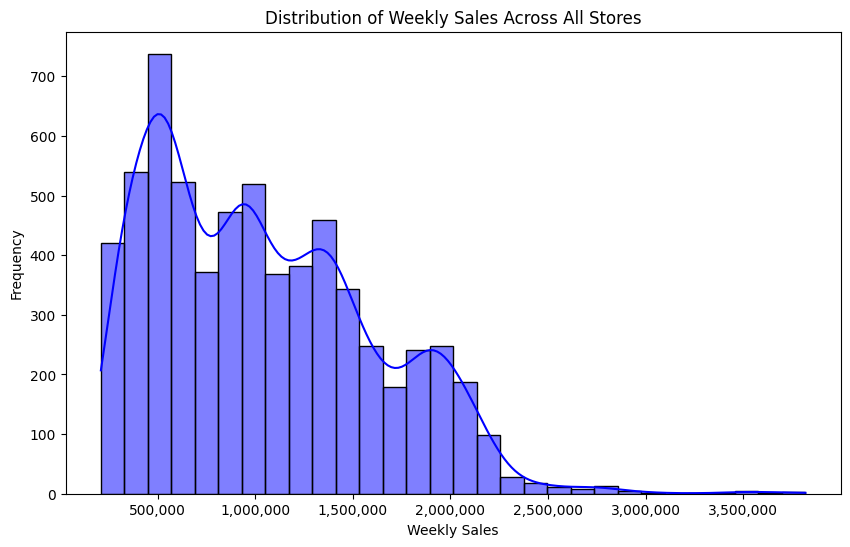

In [8]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Weekly_Sales'], kde=True, bins=30, color='blue')
plt.gca().xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: '{:,}'.format(int(x))))
plt.title("Distribution of Weekly Sales Across All Stores")
plt.xlabel("Weekly Sales")
plt.ylabel("Frequency")
plt.savefig('distribution.png', transparent=True)
plt.show()

 Most stores have weekly sales clustered around $500.000, indicating this as the usual sales performance for a majority of the weeks. Extreme sales number like $3.500.000 are very rare and can be considered as outliers.



 # 3) Weekly Sales Trend

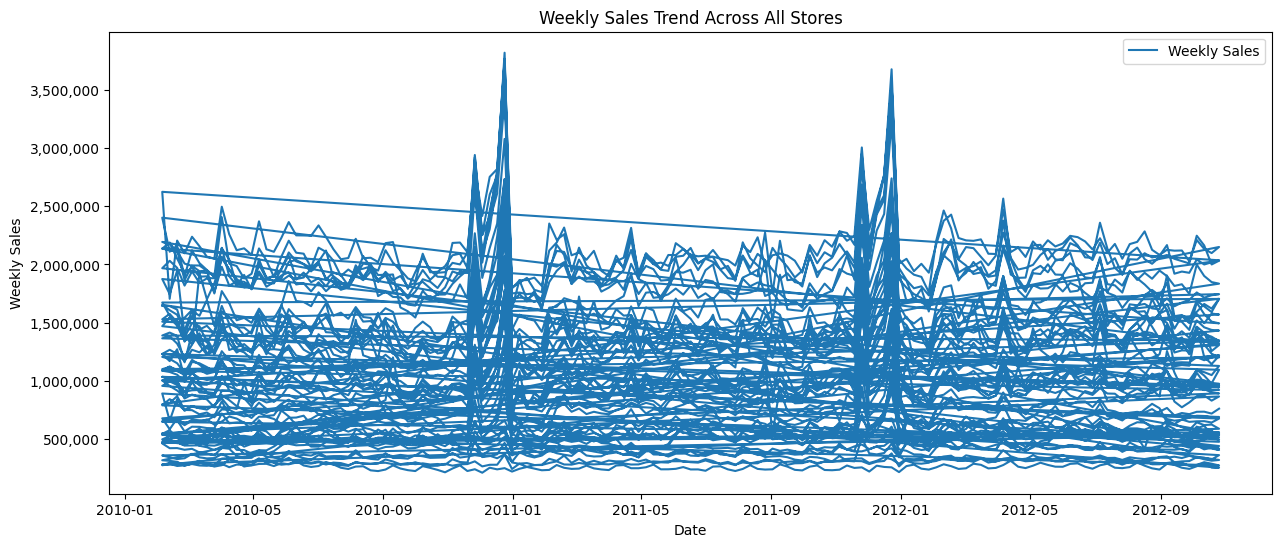

In [9]:
plt.figure(figsize=(15, 6))
plt.plot(df['Date'], df['Weekly_Sales'], label='Weekly Sales')
plt.title("Weekly Sales Trend Across All Stores")
plt.xlabel("Date")
plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, pos: '{:,}'.format(int(y))))
plt.ylabel("Weekly Sales")
plt.legend()
plt.savefig('trend.png', transparent=True)
plt.show()


 The spikes in sales around the end of 2010-start of 2011 and end of 2011-start of 2012, both surpassing $3.500.000. These spikes clearly align with the holiday and post-holiday shopping season (Christmas, New Year’s Eve, and post-holiday clearance sales).

 # 4) Correlation Heatmap

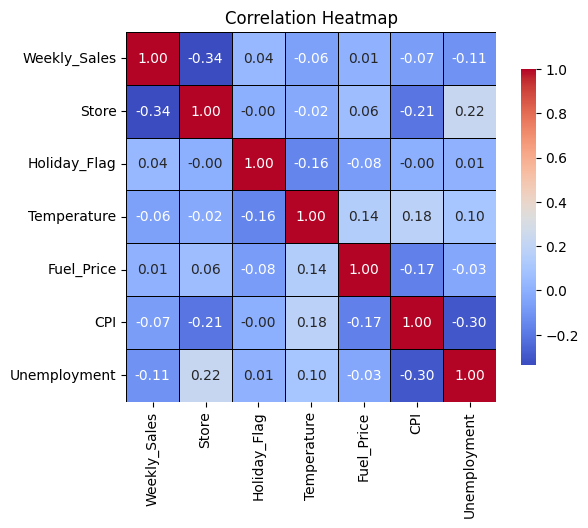

In [10]:
corr_matrix = df[['Weekly_Sales', 'Store', 'Holiday_Flag', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment']].corr()
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt='.2f', square=True, cbar_kws={"shrink": .8},linewidths=.5, linecolor='black')
plt.title("Correlation Heatmap")
plt.savefig('correlation.png', transparent=True)
plt.show()


- Store (-0.34): there is a moderate negative correlation between store number and weekly sales. As the store number increases (from Store 1 to Store 45), weekly sales tend to decrease.

 - Holiday_Flag (0.04): shows a very weak positive correlation. When there’s a holiday (Holiday_Flag = 1), sales tend to increase slightly, but the effect is so small it’s barely noticeable.

 - Temperature (-0.06): indicates a very weak negative correlation. As temperature increases, there’s a slight tendency for weekly sales to decrease, but the relationship is so weak that it’s almost negligible.

 - Fuel_Price (0.01): this means means there’s almost no relationship between fuel prices and sales. Changes in fuel prices have little to no direct impact on weekly sales at Walmart.

 - CPI (-0.07): weak negative correlation. As CPI increases (indicating rising prices for goods and services), weekly sales tend to slightly decrease — but the effect is so small it’s almost negligible

 - Unemployment (-0.11): weak negative correlation again. As unemployment increases, weekly sales tend to decrease slightly — but the effect is small.

 The weak correlations in the heatmap indicate that the features in the dataset (Holiday_Flag, Temperature, Fuel_Price, CPI, and Unemployment) do not strongly influence Weekly_Sales. This can suggest two things:

 - The dataset might be missing key predictive factors, such as promotions, advertising campaigns, or local events.

 - The relationship between these variables and sales might be non-linear or influenced by interactions between variables, which a simple correlation matrix might not reveal.


 This weak relationships between the features and Weekly_Sales could negatively impact the model’s performance to predict weekly sales as the model would not be able to learn the significant impact of each feature to weekly sales. Let’s see if this is true when we build the model later.


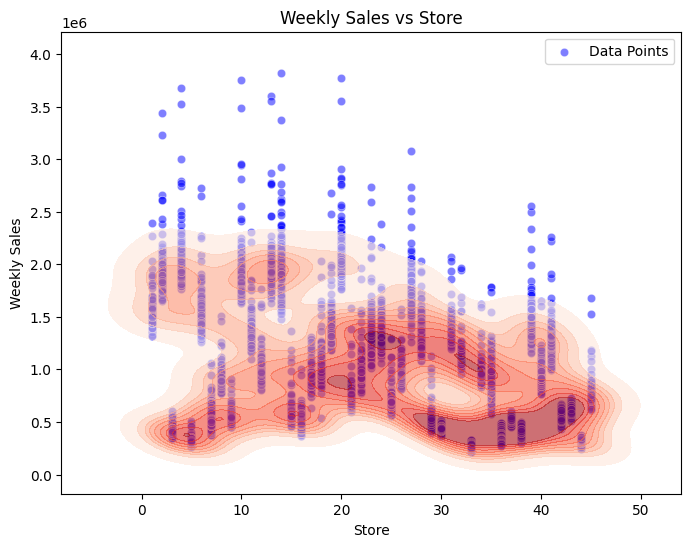

In [11]:
# Scatter Plots
plt.figure(figsize=(8, 6))
sns.scatterplot(x=df['Store'], y=df['Weekly_Sales'], alpha=0.5, color='blue', label='Data Points')
sns.kdeplot(x=df['Store'], y=df['Weekly_Sales'], cmap='Reds', fill=True, alpha=0.6, label='Density')
plt.title('Weekly Sales vs Store')
plt.xlabel('Store')
plt.ylabel('Weekly Sales')
plt.legend()
plt.savefig('store_vs_weekly_sales.png', transparent=True)
plt.show()


 The highest weekly sales occur at store 3–20. and the most dense sales happen between store 27–45. Here are the most likely explanations:

 - High Weekly Sales at Stores 3–20: These stores might be larger in size and located in wealthy neighborhoods so these stores could contribute to higher sales due to higher spending capacity. Also, these stores might have better assortment of expensive products that are in higher demand in their specific regions.

 - Dense Sales in Stores 27–45: These stores may be located in suburban areas and serve smaller communities, hence the steady (although not extraordinary) sales. Stores in this range also might be geographically close to one another, serving overlapping markets with moderate sales volume.

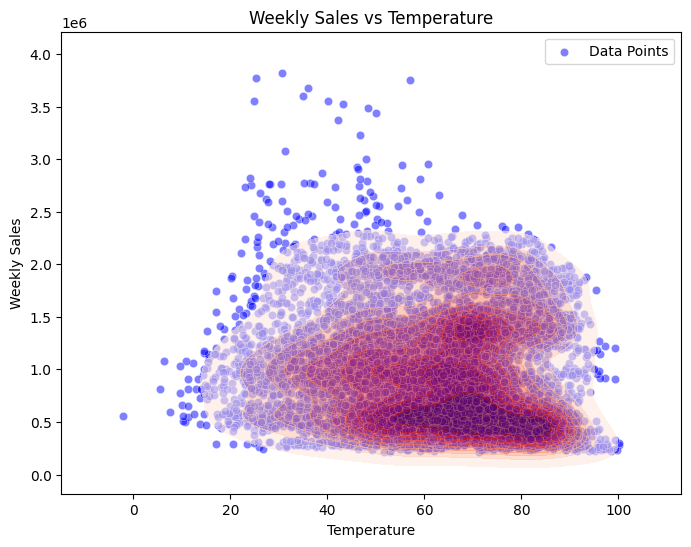

In [12]:

plt.figure(figsize=(8, 6))
sns.scatterplot(x=df['Temperature'], y=df['Weekly_Sales'], alpha=0.5, color='blue', label='Data Points')
sns.kdeplot(x=df['Temperature'], y=df['Weekly_Sales'], cmap='Reds', fill=True, alpha=0.6, label='Density')
plt.title('Weekly Sales vs Temperature')
plt.xlabel('Temperature')
plt.ylabel('Weekly Sales')
plt.legend()
plt.savefig('temperature_vs_weekly_sales.png', transparent=True)
plt.show()


 The lowest weekly sales occur when the temperature is between 0°F to 19°F. The highest weekly sales occur at temperatures between 20°F to 60°F, with the highest density of sales observed around 60°F to 80°F. The relationship between temperature and weekly sales could be influenced by consumer behavior patterns like:

 - 0°F to 19°F (Low Sales): There are few reasons why weekly sales are very low at this range. Firstly, extreme cold weather conditions (heavy snow, icy roads, and freezing temperature) could discourage people from traveling to Walmart physical stores. Secondly, consumers may stockpile before the extreme cold weather comes. Lastly, consumers may prefer online shopping, reducing in-store sales that contribute to weekly sales figures.

 - 20°F to 60°F (High Sales): This temperature range typically occurs in Spring and Fall, and it is the most favorable for shopping compared to extreme hot and cold temperatures because of comfortable shopping conditions. Also, spring is a time for home renovations, landscaping, and gardening when people spend a lot of money to buy paint, hardware, and DIY project materials for spring cleaning or redecorating. While fall is when people do back-to-school shopping then start preparing for Thanksgiving, Halloween, and even early Christmas shopping.

 - 60°F to 80°F (Dense Sales): This temperature range aligns with summer, a period when consumer outdoor-related activities are very high due to summer vacations, leading to increased leisure spending. In this period, Walmart’s customers often make smaller but frequent purchases just like groceries, snacks, barbecue supplies, outdoor equipment, beverages, etc. Also, towards the end of this period, back-to school shopping also contributes to increased weekly sales, leading to high sales density.


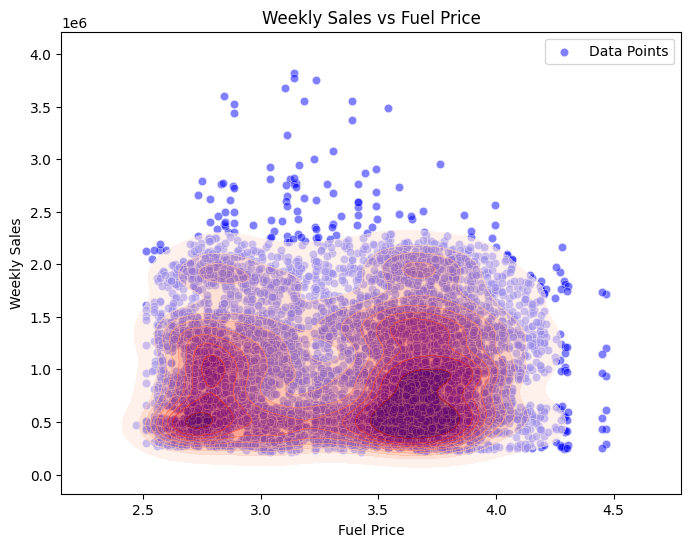

In [13]:

plt.figure(figsize=(8, 6))
sns.scatterplot(x=df['Fuel_Price'], y=df['Weekly_Sales'], alpha=0.5, color='blue', label='Data Points')
sns.kdeplot(x=df['Fuel_Price'], y=df['Weekly_Sales'], cmap='Reds', fill=True, alpha=0.6, label='Density')
plt.title('Weekly Sales vs Fuel Price')
plt.xlabel('Fuel Price')
plt.ylabel('Weekly Sales')
plt.legend()
plt.savefig('fuel_price_vs_weekly_sales.png', transparent=True)
plt.show()

 in the plot above, the highest sales occur at a different point than the high sales density because:

  - $3.0 to $3.5 (High Sales): One possible reason of high weekly sales when the fuel price is between $3.0-$3.5, is because when the range of fuel price was $2.5–$3.0, consumers may not perceive these prices as a significant economic pressure, meaning their discretionary spending on Walmart goods doesn’t dramatically change. Then a moderate rise in fuel prices ($3.0 to $3.5) happens and this lead to panic-buying behavior or stockpiling, as consumers anticipate further price increases. This drives the consumers to make larger purchases at Walmart, resulting in very high weekly sales.

 - $3.5 to $3.9 (Dense Sales): High-density sales reflect more frequent but smaller transactions, most likely caused by customers’ budget-conscious behavior. We can also notice the fact that customers still continue making frequent purchases at Walmart, even when fuel prices are in the range of $3.5–$3.9 per liter. This happens because we all know that Walmart is known for offering competitive prices, especially on essential goods like groceries, household items, and everyday necessities. When fuel prices rise, consumers may cut back on spending elsewhere but still rely on Walmart for affordable options, making frequent visits to manage their budgets.


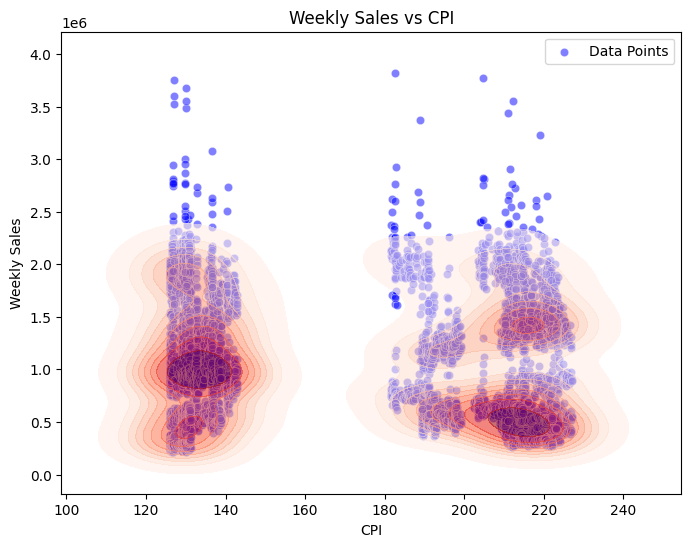

In [14]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=df['CPI'], y=df['Weekly_Sales'], alpha=0.5, color='blue', label='Data Points')
sns.kdeplot(x=df['CPI'], y=df['Weekly_Sales'], cmap='Reds', fill=True, alpha=0.6, label='Density')
plt.title('Weekly Sales vs CPI')
plt.xlabel('CPI')
plt.ylabel('Weekly Sales')
plt.legend()
plt.savefig('cpi_vs_weekly_sales.png', transparent=True)
plt.show()

 It is very possible that the ranges where there are zero sales exist because those CPI ranges (e.g, 146–179) simply do not appear in the dataset’s time period. This could happen because this dataset only covers limited specific years and the CPI during this period might have fluctuated within narrower ranges (125–145 and 180–230). And the gap (146–179) might represent a transitional range that wasn’t reached during the dataset’s timeframe.

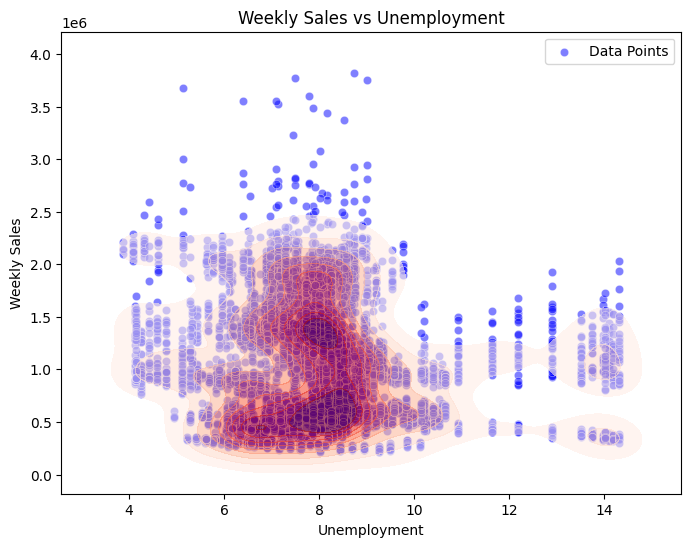

In [15]:

plt.figure(figsize=(8, 6))
sns.scatterplot(x=df['Unemployment'], y=df['Weekly_Sales'], alpha=0.5, color='blue', label='Data Points')
sns.kdeplot(x=df['Unemployment'], y=df['Weekly_Sales'], cmap='Reds', fill=True, alpha=0.6, label='Density')
plt.title('Weekly Sales vs Unemployment')
plt.xlabel('Unemployment')
plt.ylabel('Weekly Sales')
plt.legend()
plt.savefig('unemployment_vs_weekly_sales.png', transparent=True)
plt.show()

 - When the unemployment rate is around 3–5 (low), most people are employed and likely have stable incomes. Consumers may choose higher-end options. Walmart stores, known for their affordability, might not be the first choice for shoppers in this income bracket, resulting in lower and less dense sales.

 - When the unemployment rate is around 6–9 (moderate), many households experience financial strain due to job losses or reduced income. Walmart becomes a preferred shopping destination because of it’s reputation for offering affordable goods. Government support like unemployment benefits could also boost purchasing power temporarily, leading to more weekly sales at Walmart stores.

 - When the unemployment rate is around 10–15 (high), households face severe financial hardship. The drop in density indicates fewer transactions, as fewer people have the financial ability to shop regularly, even at Walmart.


 # 5) Holidays’ Impact

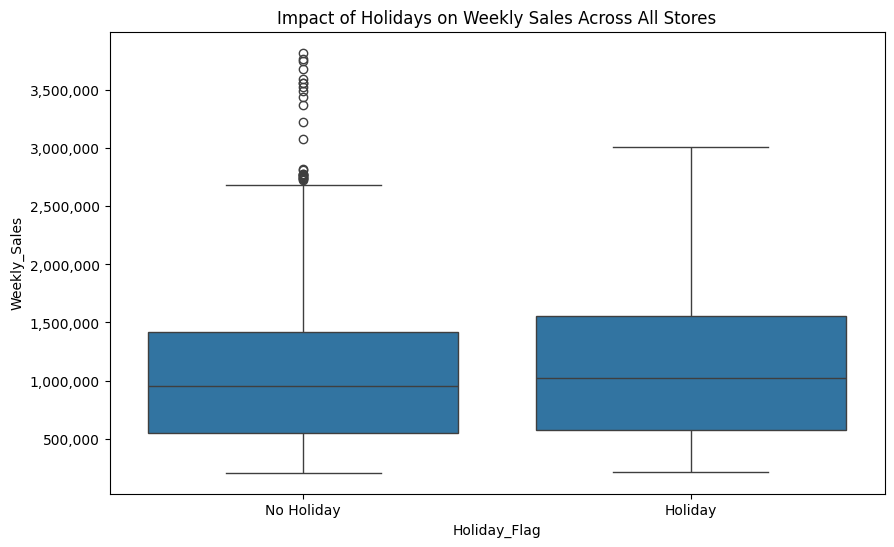

In [16]:
plt.figure(figsize=(10, 6))
plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, pos: '{:,}'.format(int(y))))
sns.boxplot(x='Holiday_Flag', y='Weekly_Sales', data=df)
plt.title("Impact of Holidays on Weekly Sales Across All Stores")
plt.xticks([0, 1], ['No Holiday', 'Holiday'])
plt.savefig('holiday.png', transparent=True)
plt.show()

 Key Components:

 - Median: The line inside the box represents the median (50th percentile), which is around 1.000.000 for both No Holiday and Holiday.

 - Interquartile Range (IQR) for No Holiday Box: The box contains Q1 (25th percentile) which is the lower part of the box — from just above $500.000 to just below $1.000.000. Followed by Q3 (75th percentile) which is the upper part of the box — from just below $1.000.000 to just below $1.500.000.

 - Interquartile Range (IQR) for Holiday Box: The box contains Q1 (25th percentile) which is the lower part of the box — from just above $500.000 to just above $1.000.000. Followed by Q3 (75th percentile) which is the upper part of the box — from just above $1.000.000 to just above $1.500.000.

 - Upper Whiskers: No Holiday ends at ~$2.700.000, with outliers up to ~$4.000.000. Holiday: ends at ~$3.000.000.

 - Lower Whiskers: represents the smallest non-outlier value in the dataset.

 Surprisingly, the highest sales occur during non-holiday weeks, even though holiday weeks have a wider range (larger whisker). This is counterintuitive as holidays typically boost sales. Investigating the reasons of these non-holiday outliers is important to make strategies for future sales growth.

 # 6) Feature Engineering:

 Extract Time-Related Features

In [18]:
df.tail(5)

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
6430,45,2012-09-28,713173.95,0,64.88,3.997,192.013558,8.684
6431,45,2012-10-05,733455.07,0,64.89,3.985,192.170412,8.667
6432,45,2012-10-12,734464.36,0,54.47,4.000,192.327265,8.667
6433,45,2012-10-19,718125.53,0,56.47,3.969,192.330854,8.667
6434,45,2012-10-26,760281.43,0,58.85,3.882,192.308899,8.667


In [19]:
df['Week_of_Year'] = df['Date'].dt.isocalendar().week
df['Month'] = df['Date'].dt.month
df['Quarter'] = df['Date'].dt.quarter

In [20]:
df.tail(5)

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Week_of_Year,Month,Quarter
6430,45,2012-09-28,713173.95,0,64.88,3.997,192.013558,8.684,39,9,3
6431,45,2012-10-05,733455.07,0,64.89,3.985,192.170412,8.667,40,10,4
6432,45,2012-10-12,734464.36,0,54.47,4.000,192.327265,8.667,41,10,4
6433,45,2012-10-19,718125.53,0,56.47,3.969,192.330854,8.667,42,10,4
6434,45,2012-10-26,760281.43,0,58.85,3.882,192.308899,8.667,43,10,4


 Explanations:

 - df[‘Week_of_Year’] = df[‘Date’].dt.isocalendar().week: this extracts the week number of the year (1 to 52 or 53 depending on the year). Weekly sales pattern could be important in time-series sales forecasting. For example, seasonal sales spikes likely occur in specific weeks of the year like Black Friday or Christmas.

 - df[‘Month’] = df[‘Date’].dt.month: this extracts the month as an integer (1 = January, 12 = December). Monthly sales trends are very likely exist in this dataset. Certain months like December may have higher sales due to Christmas and holiday shopping. While other months, especially January, might have lower sales as people cut back after the holiday season binge-shopping.

 - df[‘Quarter’] = df[‘Date’].dt.quarter: this extracts the quarter of the year as an integer (1 = Jan-Mar, 2 = Apr-Jun, 3 = Jul-Sep, 4 = Oct-Dec). Quarterly patterns may also affect sales as the fourth quarter (Q4) is a pivotal time for retail businesses, as it’s the busiest time of year for most businesses.

 - We don’t extract the day of the week because because all the data is only recorded on Fridays. Day_of_Week feature may not provide much predictive value since it doesn't vary in the dataset.


 # 7) One-Hot Encoding

In [21]:
# Apply one-hot encoding to 'Store, 'Month' and 'Quarter'
df = pd.get_dummies(df, columns=['Store', 'Month', 'Quarter'], drop_first=False)

In [22]:
df.tail(5)

,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Week_of_Year,Store_1,Store_2,...,Month_7,Month_8,Month_9,Month_10,Month_11,Month_12,Quarter_1,Quarter_2,Quarter_3,Quarter_4
6430,2012-09-28,713173.95,0,64.88,3.997,192.013558,8.684,39,False,False,...,False,False,True,False,False,False,False,False,True,False
6431,2012-10-05,733455.07,0,64.89,3.985,192.170412,8.667,40,False,False,...,False,False,False,True,False,False,False,False,False,True
6432,2012-10-12,734464.36,0,54.47,4.000,192.327265,8.667,41,False,False,...,False,False,False,True,False,False,False,False,False,True
6433,2012-10-19,718125.53,0,56.47,3.969,192.330854,8.667,42,False,False,...,False,False,False,True,False,False,False,False,False,True
6434,2012-10-26,760281.43,0,58.85,3.882,192.308899,8.667,43,False,False,...,False,False,False,True,False,False,False,False,False,True


In [23]:
df.columns

Index(['Date', 'Weekly_Sales', 'Holiday_Flag', 'Temperature', 'Fuel_Price',
       'CPI', 'Unemployment', 'Week_of_Year', 'Store_1', 'Store_2', 'Store_3',
       'Store_4', 'Store_5', 'Store_6', 'Store_7', 'Store_8', 'Store_9',
       'Store_10', 'Store_11', 'Store_12', 'Store_13', 'Store_14', 'Store_15',
       'Store_16', 'Store_17', 'Store_18', 'Store_19', 'Store_20', 'Store_21',
       'Store_22', 'Store_23', 'Store_24', 'Store_25', 'Store_26', 'Store_27',
       'Store_28', 'Store_29', 'Store_30', 'Store_31', 'Store_32', 'Store_33',
       'Store_34', 'Store_35', 'Store_36', 'Store_37', 'Store_38', 'Store_39',
       'Store_40', 'Store_41', 'Store_42', 'Store_43', 'Store_44', 'Store_45',
       'Month_1', 'Month_2', 'Month_3', 'Month_4', 'Month_5', 'Month_6',
       'Month_7', 'Month_8', 'Month_9', 'Month_10', 'Month_11', 'Month_12',
       'Quarter_1', 'Quarter_2', 'Quarter_3', 'Quarter_4'],
      dtype='object')

In [24]:
# Convert the boolean values (True/False) to integers (1/0)
for col in df.columns:
    if 'Store_' in col or 'Month_' in col or 'Quarter_' in col:
        df[col] = df[col].astype(int)

 The decision to one-hot encode Store, Month, and Quarter comes from the nature of these features:

 - Store: This represents different Walmart store locations, numbered from 1 to 45. These store numbers are categorical, not numerical with inherent relationships or order (store 1 is not “less than” store 2). Therefore, one-hot encoding avoids misleading the model into assuming any ordinal relationship between stores.

 - Month: This feature represents the calendar month (e.g., January = 1, February = 2, …, December = 12). One-hot encoding treats each month as a separate category, allowing the model to capture unique patterns associated with each month. Without one-hot encoding, the model might assume that February is closer to March than December, which is incorrect in retail weekly sales context. In retail sales context, February share more sales similarities with December (both are winter months, also December has Christmas and end year holiday, and February has a Valentine’s day) than with March, even if March is chronologically closer to February.

 - Quarter: The Quarter feature represents the fiscal quarter of the year (1, 2, 3, or 4), which groups months into broader seasonal categories. Just like months, quarters are ordinal but do not have a meaningful numerical relationship between each quarter. One-hot encoding allows the model to recognize seasonal patterns differences without imposing a false numerical relationship between quarters (e.g., Q1 being “less than” Q4)

 - One-hot encoding the Week_of_Year would create 52 extra columns. This would make the model unnecessarily complex.

 - Another reason why we shouldn’t one-hot encode Week_of_Year is because Week_of_Year is a cyclical numeric variable, which means weeks have a continuous and smooth transition. A week is only 7 days long, so week-to-week transitions are gradual and smooth. Week 50 → Week 51 → Week 52 → Week 1 follows a smooth transition and there is no major gap in behavior between adjacent weeks. Unlike Month which is less smooth because a month is longer (28–31 days) and may have sharp changes in trends: December (holiday season) → January (post-holiday sales drop).

 - Weeks are naturally continuous, while months have more distinct trends. This is why one-hot encoding is necessary for months to capture categorical differences between each month.

 Then, the reason why we should convert the encoded values to integers is because by default, pd.get_dummies()outputs True and False (boolean values), not integers. Most machine learning algorithms, especially neural networks like LSTM, expect numerical data for training. This is because the model performs mathematical operations on the data, and Booleans (True and False) would not work as intended. .astype(int) will convert True to 1 and False to 0, making the data usable for training.

 Lastly, the reason we use drop_first=False and not drop_first=True is because dropping the first column is not required for models like LSTMs because unlike linear models, LSTMs are robust and do not get confused by multicollinearity (redundant features). Having all the one-hot encoded columns without dropping the first one is completely acceptable because LSTMs focus on sequence patterns, not correlations between features.


In [25]:
# Result:

df.tail()


,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Week_of_Year,Store_1,Store_2,...,Month_7,Month_8,Month_9,Month_10,Month_11,Month_12,Quarter_1,Quarter_2,Quarter_3,Quarter_4
6430,2012-09-28,713173.95,0,64.88,3.997,192.013558,8.684,39,0,0,...,0,0,1,0,0,0,0,0,1,0
6431,2012-10-05,733455.07,0,64.89,3.985,192.170412,8.667,40,0,0,...,0,0,0,1,0,0,0,0,0,1
6432,2012-10-12,734464.36,0,54.47,4.000,192.327265,8.667,41,0,0,...,0,0,0,1,0,0,0,0,0,1
6433,2012-10-19,718125.53,0,56.47,3.969,192.330854,8.667,42,0,0,...,0,0,0,1,0,0,0,0,0,1
6434,2012-10-26,760281.43,0,58.85,3.882,192.308899,8.667,43,0,0,...,0,0,0,1,0,0,0,0,0,1


 # 8) Split the Data

In [26]:
# Define the features
features = (
    [col for col in df.columns if col.startswith('Month_')] +  # Add one-hot encoded 'Month' columns
    [col for col in df.columns if col.startswith('Quarter_')] +  # Add one-hot encoded 'Quarter' columns
    ['Week_of_Year', 'Holiday_Flag', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment']  # Add the rest
)


In [27]:
features

['Month_1',
 'Month_2',
 'Month_3',
 'Month_4',
 'Month_5',
 'Month_6',
 'Month_7',
 'Month_8',
 'Month_9',
 'Month_10',
 'Month_11',
 'Month_12',
 'Quarter_1',
 'Quarter_2',
 'Quarter_3',
 'Quarter_4',
 'Week_of_Year',
 'Holiday_Flag',
 'Temperature',
 'Fuel_Price',
 'CPI',
 'Unemployment']

In [28]:
# Define the target
target = 'Weekly_Sales'

X = df[features]
y = df[target]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)


 This code prepares the data for the LSTM model to predict Weekly_Sales using exogenous features.

 - col.startswith('Month_'): Automatically identifies all the one-hot encoded columns for Month.

 - col.startswith('Quarter_'): Automatically identifies all the one-hot encoded columns for Quarter.

 - The rest of the features ( Week_of_Year, Holiday_Flag, etc.) are included directly in the features list.

 - The data is split into training (80%) and testing (20%) sets.

 - shuffle=False is used in the train_test_split() function to ensure that the data is not shuffled before it’s split into training and testing sets. This keeps the data in it’s natural time order. The training data contains past data, and the testing contains future data, mimicking a real-world scenario where the model forecasts future values.

# 9) Scale the Data

About LSTMs

Basically LSTMs are machine learning models that rely on gradient-based optimization. When the input features have very large or small values, it can cause gradients to either explode (become too large and destabilize training) or vanish (become to small, slowing down learning or stopping it entirely). This requires the input values to be bounded between fixed ranges that aligns well with the active functions like sigmoid or tanh ([0,1] for sigmoid and [-1,-1] for tanh) .

We could use MinMaxScaler() to rescale the input values to a range of [0.1]. This makes all features contribute equally to the learning process of the model. And if the input values are not normalized (scaled), they may fall outside the operating range and could lead to poor model performance.

Sigmoid is used in gates (forget gate, input gate, and output gate) because it outputs values between 0 and 1, which are useful to control how much information to keep or throw away. Think of this like a water faucet: 0 means “fully closed” (no water flows), and 1 means “fully open” (water flows fully), and any number between those two means the faucet is neither fully open nor fully closed.

Tanh is used to update the cell state, which is like a memory bank where information is stored over time. LSTMs update this memory in small steps as it processes the data.

- Positive adjustments is when tanh outpus a positive value (close to 1). This is where LSTMs add positive information to the memory. Example: the model observes a repeated pattern where sales consistently increase during holidays, then the model updates it’s cell state (memory) to remember that holidays are associated with higher sales.

- Negative adjustments is when tanh outputs a negative values (close to -1). This is where LSTMs remove outdated or unnecessary information. Example: In spring, weekly sales correlate with rising fuel prices (e.g., $3–$3.5). While in fall, weekly sales start correlating with pre-holiday shopping instead. The LSTM then can realize that the spring patterns (fuel prices) are no longer relevant in fall. The forget gate suppresses spring-related patterns and prioritizes fall-related ones, ensuring the model adapts to changes over time.

This code below applies MinMaxScaler() to the features (X) and the target (y) to transform their original values into a normalized range between 0 and 1. This scaling helps improve the performance of the LSTM model that is sensitive to the magnitude of the data.

In [29]:
X_train.tail(20)

,Month_1,Month_2,Month_3,Month_4,Month_5,Month_6,Month_7,Month_8,Month_9,Month_10,...,Quarter_1,Quarter_2,Quarter_3,Quarter_4,Week_of_Year,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
5128,0,0,0,0,0,1,0,0,0,0,...,0,1,0,0,24,0,82.15,3.407,220.449415,6.989
5129,0,0,0,0,0,1,0,0,0,0,...,0,1,0,0,25,0,80.40,3.358,220.488647,6.989
5130,0,0,0,0,0,1,0,0,0,0,...,0,1,0,0,26,0,86.68,3.273,220.527880,6.989
5131,0,0,0,0,0,0,1,0,0,0,...,0,0,1,0,27,0,81.52,3.232,220.567112,6.623
5132,0,0,0,0,0,0,1,0,0,0,...,0,0,1,0,28,0,78.15,3.245,220.606344,6.623
5133,0,0,0,0,0,0,1,0,0,0,...,0,0,1,0,29,0,81.76,3.301,220.614875,6.623
5134,0,0,0,0,0,0,1,0,0,0,...,0,0,1,0,30,0,84.00,3.392,220.623405,6.623
5135,0,0,0,0,0,0,0,1,0,0,...,0,0,1,0,31,0,85.56,3.404,220.631936,6.623
5136,0,0,0,0,0,0,0,1,0,0,...,0,0,1,0,32,0,84.41,3.490,220.640466,6.623
5137,0,0,0,0,0,0,0,1,0,0,...,0,0,1,0,33,0,85.89,3.571,220.719961,6.623


In [30]:
X_test.tail(10)

,Month_1,Month_2,Month_3,Month_4,Month_5,Month_6,Month_7,Month_8,Month_9,Month_10,...,Quarter_1,Quarter_2,Quarter_3,Quarter_4,Week_of_Year,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
6425,0,0,0,0,0,0,0,1,0,0,...,0,0,1,0,34,0,72.62,3.834,191.344887,8.684
6426,0,0,0,0,0,0,0,1,0,0,...,0,0,1,0,35,0,75.09,3.867,191.461281,8.684
6427,0,0,0,0,0,0,0,0,1,0,...,0,0,1,0,36,1,75.70,3.911,191.577676,8.684
6428,0,0,0,0,0,0,0,0,1,0,...,0,0,1,0,37,0,67.87,3.948,191.699850,8.684
6429,0,0,0,0,0,0,0,0,1,0,...,0,0,1,0,38,0,65.32,4.038,191.856704,8.684
6430,0,0,0,0,0,0,0,0,1,0,...,0,0,1,0,39,0,64.88,3.997,192.013558,8.684
6431,0,0,0,0,0,0,0,0,0,1,...,0,0,0,1,40,0,64.89,3.985,192.170412,8.667
6432,0,0,0,0,0,0,0,0,0,1,...,0,0,0,1,41,0,54.47,4.000,192.327265,8.667
6433,0,0,0,0,0,0,0,0,0,1,...,0,0,0,1,42,0,56.47,3.969,192.330854,8.667
6434,0,0,0,0,0,0,0,0,0,1,...,0,0,0,1,43,0,58.85,3.882,192.308899,8.667


In [31]:
# Min-Max Scaling for features and target
scaler_X = MinMaxScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.fit_transform(X_test)

In [32]:
X_train_scaled[:2]

array([[0.        , 1.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 1.        , 0.        , 0.        ,
        0.        , 0.07843137, 0.        , 0.43414873, 0.0501002 ,
        0.84049976, 0.40511788],
       [0.        , 1.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 1.        , 0.        , 0.        ,
        0.        , 0.09803922, 1.        , 0.39696673, 0.03807615,
        0.84194103, 0.40511788]])

In [33]:
X_test_scaled[:2]

array([[0.        , 1.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 1.        , 0.        , 0.        ,
        0.        , 0.07843137, 0.        , 0.40642069, 0.0296827 ,
        0.8723505 , 0.43472713],
       [0.        , 1.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 1.        , 0.        , 0.        ,
        0.        , 0.09803922, 1.        , 0.40798127, 0.0174002 ,
        0.8738503 , 0.43472713]])

In [34]:
scaler_y = MinMaxScaler()
y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1))
y_test_scaled = scaler_y.transform(y_test.values.reshape(-1, 1))


In [35]:
X_train_scaled[:2]

array([[0.        , 1.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 1.        , 0.        , 0.        ,
        0.        , 0.07843137, 0.        , 0.43414873, 0.0501002 ,
        0.84049976, 0.40511788],
       [0.        , 1.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 1.        , 0.        , 0.        ,
        0.        , 0.09803922, 1.        , 0.39696673, 0.03807615,
        0.84194103, 0.40511788]])

In [36]:
X_test_scaled[:2]

array([[0.        , 1.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 1.        , 0.        , 0.        ,
        0.        , 0.07843137, 0.        , 0.40642069, 0.0296827 ,
        0.8723505 , 0.43472713],
       [0.        , 1.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 1.        , 0.        , 0.        ,
        0.        , 0.09803922, 1.        , 0.40798127, 0.0174002 ,
        0.8738503 , 0.43472713]])

In [37]:

# Convert to DataFrame
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns)

# Display the first few rows
print(X_train_scaled_df.head())

   Month_1  Month_2  Month_3  Month_4  Month_5  Month_6  Month_7  Month_8  \
0      0.0      1.0      0.0      0.0      0.0      0.0      0.0      0.0   
1      0.0      1.0      0.0      0.0      0.0      0.0      0.0      0.0   
2      0.0      1.0      0.0      0.0      0.0      0.0      0.0      0.0   
3      0.0      1.0      0.0      0.0      0.0      0.0      0.0      0.0   
4      0.0      0.0      1.0      0.0      0.0      0.0      0.0      0.0   

   Month_9  Month_10  ...  Quarter_1  Quarter_2  Quarter_3  Quarter_4  \
0      0.0       0.0  ...        1.0        0.0        0.0        0.0   
1      0.0       0.0  ...        1.0        0.0        0.0        0.0   
2      0.0       0.0  ...        1.0        0.0        0.0        0.0   
3      0.0       0.0  ...        1.0        0.0        0.0        0.0   
4      0.0       0.0  ...        1.0        0.0        0.0        0.0   

   Week_of_Year  Holiday_Flag  Temperature  Fuel_Price       CPI  Unemployment  
0      0.078431  

# Feature Scaling for Inputs

The features are scaled to a range of [0,1] which aligns well with the requirements of sigmoid and tanh activations.
fit_transform is only applied to the training set to calculate the scaling parameters which are min and max.
transform is applied to the test set using the same scaling parameters learned from the training set to ensure consistency, which means we don’t have to use fit_transform again.

# Feature Scaling for Outputs
    
scaler_y.fit_transform(y_train.values.reshape(-1, 1)) reshapes the target data to 2D format so it can be processed by the MinMaxScaler().
Same as the inputs, we use fit_transform for the training set and transform for the test set.

# 10) Data Preparation for RNN

This code below is responsible for preparing data sequences for training and testing a Recurrent Neural Network (RNN) model, specifically an LSTM.

This code converts a dataset (X, y) into a format where each input sequence contains a fixed number of steps (time_steps), and each corresponding target is the value right after the sequence. Example: with time_steps=4, the RNN sees the data for 4time steps to predict the value at the 5th step, and so on.



In [38]:
# Function to create sequences for RNN
def create_sequences(X, y, time_steps=4):
    Xs, ys = [], []
    for i in range(len(X) - time_steps):
        Xs.append(X[i:i + time_steps])
        ys.append(y[i + time_steps])
    return np.array(Xs), np.array(ys)

time_steps = 4
X_train_seq, y_train_seq = create_sequences(X_train_scaled, y_train_scaled, time_steps)
X_test_seq, y_test_seq = create_sequences(X_test_scaled, y_test_scaled, time_steps)

### The create_sequences Function

This function converts data into sequences for time-series modeling. Xs holds the sequences of X features (past observations fo multiple time steps), and ys holds the corresponding y targets (future values to predict).

### The sliding window approach

This approach is used to create overlapping sequences.

Example with time_steps=4:

X: [1, 2, 3, 4, 5, 6, 7, 8]

y: [6, 7, 8, 9, 10]

With time_steps=4, we will create sequences of 4 consecutive values from X and the corresponding target value from y will be the value that comes immediately after the sequence.



Xs( Sequences of 4 elements):

First sequence: [1, 2, 3, 4] → Corresponding y: 6

Second sequence: [2, 3, 4, 5] → Corresponding y: 7

Third sequence: [3, 4, 5, 6] → Corresponding y: 8

Fourth sequence: [4, 5, 6, 7] → Corresponding y: 9

Fifth sequence: [5, 6, 7, 8] → Corresponding y: 10

Result of Xs:

Xs

[[1, 2, 3, 4],

 [2, 3, 4, 5],
 
 [3, 4, 5, 6],
 
 [4, 5, 6, 7],
 
 [5, 6, 7, 8]]

 ys (corresponding target values):


[6, 7, 8, 9, 10]


The sliding window approach is beautifully done!

conclusion: time_steps=4 → Uses the past 4 weeks to predict the sales for the next week.





## 11) Create Training and Testing Sequences

Then, we should use return np.array(Xs), np.array(ys) to convert lists to NumPy arrays because most ML/DL frameworks (in this case, Tensorflow) require array-like inputs.

Lastly, we create training and testing sequences:

- time_steps=4: The model use 4consecutive observations to predict the next target value.

- create_sequences(X_train_scaled, y_train_scaled, time_steps) converts the scaled training data into sequences. X_train_seq contains input sequences for training, and y_train_seq contains corresponding target values for training.

- create_sequences(X_test_scaled, y_test_scaled, time_steps) performs the same transformation for the test set.

Further Explanations

- RNNs (in this case, an LSTM) are designed to model temporal dependencies, making them ideal for time-series analysis projects. Thus, sequences allow the model to capture patterns over time.

- The sliding windows approach is used to increase the amount of training data without requiring new data because it ensures the model learns from all possible patterns in the dataset.

- We use time_steps=4 because using a sequence of 4 weeks (or a monthly window) will give the model more context to capture seasonal patterns.


# 12) Build the LSTM Model

This step is used to build, compile, and train the LSTM model using Keras. The LSTM is designed to predict a single output, which is Weekly_Sales, based on sequential input data (time_steps sequences).

In [39]:
# Define the RNN Model:

# Define the RNN model with default LSTM settings
model = Sequential([
    LSTM(64, input_shape=(time_steps, X_train_seq.shape[2]), return_sequences=True),  # Default activations
    LSTM(32),  # Default activations
    Dense(1)  # Output layer
])


/home/fabiene/anaconda3/envs/YouTube/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


- Sequential is a Keras class used to stack layers sequentially, and those layers are executed in the order they are added.

- LSTM(64) creates an LSTM layer with 64 neurons in it’s hidden state.

- time_steps: Number of time steps in each sequence.

- X_train_seq.shape[2]: Number of features in each time step (e.g., features like Store, Temperature, etc.). return_sequences=True ensures that the output of this LSTM layer contains a sequence for each time step.

- LSTM(32) is a second LSTM layer with 32 units. By default, it uses return_sequences=False, so it outputs only the final hidden state (not a sequence).

- Dense(1) is a fully connected layer with a single output neuron. This predicts a single continous value (in this case, Weekly_Sales)


## Compile the Model


In [40]:
model

<Sequential name=sequential, built=True>

In [41]:
# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mean_absolute_error'])

- optimizer='adam': Adam (Adaptive Moment Estimation) is a widely used optimizer for deep learning tasks due to it’s quick nature in improving training speeds in neural networks and reaching convergence quickly

- loss='mean_squared_error': MSE is used because it’s suitable as a loss function for regression tasks to predict continuous values (in this case, predicting weekly sales)

- metrics=['mean_absolute_error']: MAE provides an interpretable metric (average error in the same units as the target).

## Train the Model


In [42]:
# Train the model
history = model.fit(
    X_train_seq, y_train_seq, 
    validation_data=(X_test_seq, y_test_seq), 
    epochs=50, 
    batch_size=32, 
    verbose=1
)

Epoch 1/50
161/161 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0287 - mean_absolute_error: 0.1393 - val_loss: 0.0253 - val_mean_absolute_error: 0.1398
Epoch 2/50
161/161 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0248 - mean_absolute_error: 0.1308 - val_loss: 0.0208 - val_mean_absolute_error: 0.1277
Epoch 3/50
161/161 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0245 - mean_absolute_error: 0.1303 - val_loss: 0.0252 - val_mean_absolute_error: 0.1405
Epoch 4/50
161/161 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0231 - mean_absolute_error: 0.1260 - val_loss: 0.0204 - val_mean_absolute_error: 0.1267
Epoch 5/50
161/161 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0239 - mean_absolute_error: 0.1295 - val_loss: 0.0234 - val_mean_absolute_error: 0.1331
Epoch 6/50
161/161 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0235 - mean_absolute_error: 0.1272 - val_loss: 0.0272 - val_mean_absolute_error: 0.1464
Epoch 7/50
161/161 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0230 - mean_absolute_error: 0.1260 - v

In [43]:
history

- X_train_seq, y_train_seq: Training data (sequences of input features and their corresponding targets).

- validation_data=(X_test_seq, y_test_seq): Validation data is used to monitor model performance during training.

- epochs=50: the LSTM is trained for 50 complete passes through the training data.

Here are the first few epochs in the training log output:

We can notice that the performance starts to deteriorate from Epoch 8 onward.

- Epochs 1–7: the training loss (loss) is consistently decreasing, and the validation loss (val_loss) is also either decreasing or staying stable, suggesting the model is improving on both the training data and unseen data (validation set).

- Epoch 8: the validation loss begins to increase again, from 0.0162 in Epoch 7 to 0.0214 in Epoch 8. This increase suggests the model is starting to overfit the training data.

- Epochs 9–17: the training loss continues to decrease or remain relatively low, but the validation loss is fluctuating or increasing (with minor decreases). This is a clear sign of overfitting: the model is continuing to improve it’s performance on the training data but is failing to generalize well to the validation set.


## 13) Model Evaluation


In [44]:
# Predict on test data
y_pred_scaled = model.predict(X_test_seq)
y_pred = scaler_y.inverse_transform(y_pred_scaled)

# Rescale the test target to original scale
y_test_actual = scaler_y.inverse_transform(y_test_seq)

# Calculate evaluation metrics
mae = mean_absolute_error(y_test_actual.flatten(), y_pred.flatten())
rmse = mean_squared_error(y_test_actual.flatten(), y_pred.flatten(), squared=False)

print(f"\n=====Evaluation Metrics=====")
print(f"Mean Absolute Error (MAE): {mae}")
print(f"Root Mean Squared Error (RMSE): {rmse}")

41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step

=====Evaluation Metrics=====
Mean Absolute Error (MAE): 649322.080751291
Root Mean Squared Error (RMSE): 756386.9487525277


/home/fabiene/anaconda3/envs/YouTube/lib/python3.12/site-packages/sklearn/metrics/_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


MAE (Mean Absolute Error) measures the average absolute difference between actual and predicted values. In other words, it tells you how much the model’s predictions deviate from the actual values. This evaluation method is less sensitive to outliers since it doesn’t square the errors.

RMSE (Root Mean Squared Error) measures the square root of the average squared differences between actual and predicted values. This evaluation method gives a higher penalty to big mistakes compared to MAE because this method is more sensitive to large errors.

To evaluate the model, we combine Mean Absolute Error (MAE) and Root Mean Squared Error (RMSE) to evaluate a model because of several reasons:

- MAE gives us a more interpretable measure. For example:
“on average, predictions are off by $488.889”

- RMSE gives more weight to large errors. This helps us assess if the model makes big mistakes sometimes.

- If RMSE is much higher than MAE, it suggests the presence of outliers or extreme errors. Example: week 1 has $20.000 error (e.g, actual sales is $1.000.000 and predicted sales is $1.020.000), week 2 has $30,000 error, week 3 has $40.000 error, week 4 has $50.000 error, then suddenly week 5 has a skyrocketed error of $650.000. This would result in much higher RMSE compared to the MAE.

- If RMSE is equal to MAE, or at least close to MAE, then the errors are evenly distributed, which means that the model makes consistent-sized errors.

In [45]:

print(f"\n=====Evaluation Metrics=====")
print(f"Mean Absolute Error (MAE): {mae}")
print(f"Root Mean Squared Error (RMSE): {rmse}")


=====Evaluation Metrics=====
Mean Absolute Error (MAE): 649322.080751291
Root Mean Squared Error (RMSE): 756386.9487525277


MAE = 647756 → On average, the predictions were off by $647756.

RMSE = 748825 → Some large mistakes made the overall error higher, with an average squared error of $748825.

MAE = 488,889 → On average, the predictions were off by $488,889.

RMSE = 570,091 → Some large mistakes made the overall error higher, with an average squared error of $570,091.

# Actual vs Predicted Sales


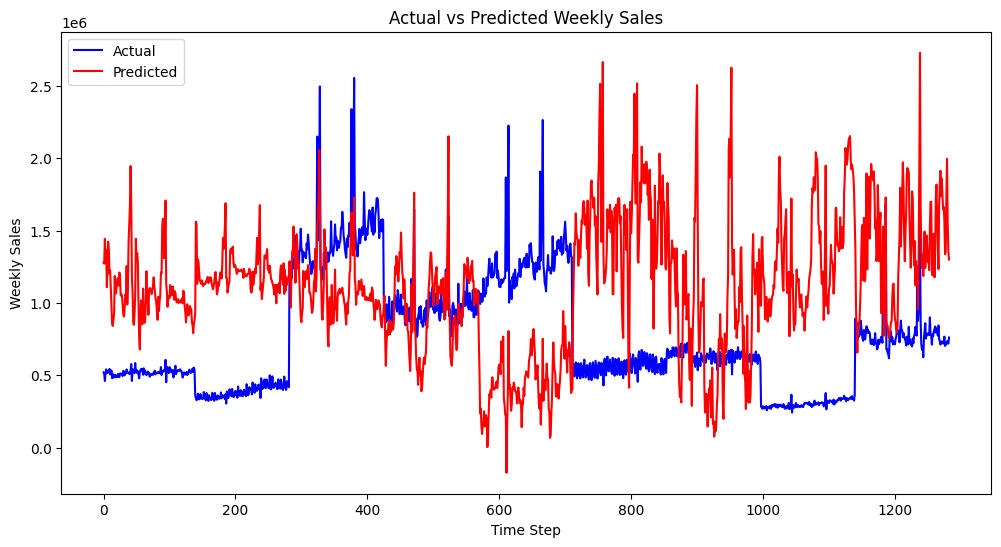

In [46]:
# Plot actual vs predicted values
plt.figure(figsize=(12, 6))
plt.plot(y_test_actual.flatten(), label='Actual', color='blue')
plt.plot(y_pred.flatten(), label='Predicted', color='red')
plt.legend()
plt.title('Actual vs Predicted Weekly Sales')
plt.xlabel('Time Step')
plt.ylabel('Weekly Sales')
plt.savefig('Predicted_Sales.png',transparent=True)
plt.show()

This model performs very badly, therefore we should try to perform hyperparameter tuning to improve the performance of the model.

# 14) Hyperparameter Tuning

Previously, the default hyperparameter may not be suitable and not performing very well on the dataset. Tuning the hyperparameters by increasing/decreasing the number of LSTM units, learning rate, batch size, and the number of epochs could significantly improves the model’s performance. This could help the model to achieve better evaluation metrics (in this case, MAE and RMSE).


## Define a Function to Build the Model for Hyperparameter Tuning

In this step, we build a function called build_model to define a tunable LSTM model for time-series prediction. This function uses Keras Tuner to search for various hyperparameter combinations.



In [47]:
# Define a function to create the model
def build_model(hp):
    model = Sequential()
    
    # Tune the number of LSTM units in the first LSTM layer
    model.add(LSTM(
        hp.Int('units_1', min_value=32, max_value=128, step=32),  # Hyperparameter to tune
        input_shape=(time_steps, X_train_seq.shape[2]),
        return_sequences=True
    ))
    
    # Add second LSTM layer
    model.add(LSTM(
        hp.Int('units_2', min_value=16, max_value=64, step=16)  # Hyperparameter to tune
    ))
    
    # Add Dropout layer to prevent overfitting
    model.add(Dropout(hp.Float('dropout_rate', min_value=0.2, max_value=0.5, step=0.1)))
    
    # Output layer
    model.add(Dense(1))
    
    # Tune the learning rate
    model.compile(
        optimizer=Adam(learning_rate=hp.Float('learning_rate', min_value=1e-5, max_value=1e-2, sampling='log')),
        loss='mean_squared_error',
        metrics=['mean_absolute_error']
    )
    
    return model

First layer:

- hp.Int(‘units_1’, min_value=32, max_value=128, step=32): 32 units are a reasonable starting point for LSTM layers. Small enough to avoid overfitting but at the same time still capable of capturing patterns. While 128 units provide sufficient capacity without becoming computationally excessive. Lastly, step=32 means that this layer increments by 32 (32, 64, 96, 128).
  
- input_shape=(time_steps, X_train_seq.shape[2]): time_steps in this line of code represents the number of steps in the input sequence (4 in this project).

- X_train_seq.shape[2]: the number of features in each time step.

- return_sequences=True: this line of code outputs the full sequence, which is necessary to stack another LSTM layer that expects sequential data as input.

Second layer:

- hp.Int(‘units_2’, min_value=16, max_value=64, step=16): A second LSTM layer tends to be smaller in size due to the fact that it often acts as a bottleneck to condense the information from the first layer into a more compact form. That is why this layer have smaller units than the first one.
 
- return_sequences=False: Outputs the final hidden state of the sequence. This is the default for the last LSTM layer before the dense output layer.


Dropout layer:

- model.add(Dropout(hp.Float(‘dropout_rate’, min_value=0.2, max_value=0.5, step=0.1))): A dropout rate below 0.2 is usually ineffective for regularization, and a dropout above 0.5 can cause underfitting so 0.5 is a reasonable upper limit. While step size of 0.1 ensures to find the most effective dropout rate in increments 0.1 (0.2, 0.3, 0.4, and 0.5). It’s important to note that using larger sizes means fewer values would be tested, which can speed up the tuning process, but at the same time may miss more optimal values (e.g, using step=0.2 means you will miss 0.3). It’s a trade-off between tuning speed and precision in finding the best hyperparameter value.


Dense layer:

- model.add(Dense(1)): A fully connected layer with a single neuron outputs the predicted value for regression tasks (in this case, a sales forecasting task).
 
Model compilation:

- min_value=1e-5 ensures the model learns slowly to avoid overshooting.

- min_value=1e-2 ensures the model has faster convergence but still avoid overshooting.

- sampling=’log’ is ideal for learning rates because it is better to test values that are spread out exponentially (0.001, 0.01, 0.1) rather than evenly spaced values (0.01, 0.02, 0.03). Testing values between 10⁻⁵ (0.00001) and 10⁻² (0.01) ensures both very small and relatively large learning rates are explored.

# 15) Define the Hyperparameter Search Space

This code below sets up a Random Search (using a Keras Tuner library, kt.RandomSearch). The purpose of this search method is to find the best combination of hyperparameters for the LSTM model.

In [48]:
# Define the tuner using Random Search
tuner = kt.RandomSearch(
    build_model,
    objective='val_loss',  # We want to minimize validation loss
    max_trials=10,  # Number of different combinations to try
    executions_per_trial=1,  # Number of trials to run for each combination
    directory='my_dir',  # Directory to save the results
    project_name='LSTM_tuning'
)

/home/fabiene/anaconda3/envs/YouTube/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


- build_model is the function we built earlier that’s used to define the model.

- objective=’val_loss’ means that the model will be trained on different combinations of hyperparameters, and the one that gives the lowest validation loss will be chosen because it that model generalizes well to unseen data.

- max_trials=10 specifies the maximum number of different hyperparameter combinations that will be tried during the tuning process.
executions_per_trial=1 refers to the number of times the model will be trained with the same set of hyperparameters.

- directory=’my_dir’ is the directory where the hyperparameter search’s results will be saved.

- project_name=’LSTM_tuning’ is the name of the project of the current hyperparameter search that will be used to group all the 10 trials.

In [51]:
tuner

# 16) Run the Hyperparameter Search

This code below will test different hyperparameter combinations to find the best performing LSTM model

In [52]:
# Start the hyperparameter search
tuner.search(
    X_train_seq, y_train_seq,  # Training data
    epochs=50,  # Number of epochs to train each model for
    batch_size=32,  # Batch size
    validation_data=(X_test_seq, y_test_seq)  # Validation data
)

Trial 10 Complete [00h 01m 08s]
val_loss: 0.021433593705296516

Best val_loss So Far: 0.012093653902411461
Total elapsed time: 00h 11m 50s


- tuner.search(X_train_seq, y_train_seq, runs the hyperparameter tuning on the training dataset. X_train_seq contains the input sequences (historical data that the model uses to make predictions), while y_train_seq contains the corresponding labels (target values that the model is trying to predict, based on the input sequences).

- Each hyperparameter tuning sequence trains the model for 50 epochs.

- 32 is a standard batch size, often recommended as a good default value. This batch size takes 32 samples, computes predictions, calculates errors, updates weights, and then moves to the next sample. For example, if we had 100.000 samples, the model would divide them into mini-batches of 32 and update the weights after each batch, rather than waiting to see all 100.000 samples first. Batch size of 32 provides us with faster training process due to more frequent updates and more stable learning by avoiding extreme updates from the entire dataset at once.

- The model is frequently evaluated on the validation set (X_test_seq, y_test_seq) after each epoch to check how well the model works on unseen data. This process is essential to prevent overfitting.

# 17) Get the Best Hyperparameters

This step retrieves the best hyperparameter found by the tuner.

In [53]:
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
print(f"Best hyperparameters: {best_hps.values}")

Best hyperparameters: {'units_1': 32, 'units_2': 16, 'dropout_rate': 0.4, 'learning_rate': 8.030512585141102e-05}


- num_trials=1 means we only want the single best set of hyperparameters, out of all trials. Even though we only want the best one, the method still returns it inside a list.

- Then [0] extracts that best set of hyperparameter from the list. We use [0] because we don’t need the list, we only need the set (the value inside the list).

# 18) Train the Final Model with Best Hyperparameters

This step trains the final LSTM model using the best hyperparameters. This code also applies early stopping to prevent overfitting.

In [54]:
# Build the model with the best hyperparameters
model = tuner.hypermodel.build(best_hps)
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Train the final model
history = model.fit(
    X_train_seq, y_train_seq, 
    validation_data=(X_test_seq, y_test_seq),
    epochs=50, 
    batch_size=32, 
    verbose=1,
    callbacks=[early_stopping]
)

Epoch 1/50
161/161 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0749 - mean_absolute_error: 0.2194 - val_loss: 0.0162 - val_mean_absolute_error: 0.1089
Epoch 2/50
161/161 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0346 - mean_absolute_error: 0.1477 - val_loss: 0.0205 - val_mean_absolute_error: 0.1260
Epoch 3/50
161/161 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0307 - mean_absolute_error: 0.1421 - val_loss: 0.0196 - val_mean_absolute_error: 0.1241
Epoch 4/50
161/161 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0308 - mean_absolute_error: 0.1424 - val_loss: 0.0204 - val_mean_absolute_error: 0.1268
Epoch 5/50
161/161 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0284 - mean_absolute_error: 0.1372 - val_loss: 0.0203 - val_mean_absolute_error: 0.1266
Epoch 6/50
161/161 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0287 - mean_absolute_error: 0.1378 - val_loss: 0.0214 - val_mean_absolute_error: 0.1299


- monitor='val_loss': The model stops training if validation loss doesn’t improve.
    
- patience=5: If validation loss doesn't improve for 5 consecutive epochs, training stops.

- restore_best_weights=True: Ensures the model keeps the weights from the best epoch (not the last one).


We can notice that training process stopped at epoch 6 because of early stopping.

- The validation loss got worse after epoch 1 (0.0134 → 0.0155 → 0.0191 → … → 0.0232).

- So, after waiting for 5 epochs (epochs 2–6), training stopped automatically.

- This prevents overfitting by stopping when the model no longer improves. This model already learned a good pattern quickly, and no further training process is required.

# 19) Final Model Evaluation


In [55]:
# Predict on test data
y_pred_scaled = model.predict(X_test_seq)
y_pred = scaler_y.inverse_transform(y_pred_scaled)

# Rescale the test target to original scale
y_test_actual = scaler_y.inverse_transform(y_test_seq)

# Calculate evaluation metrics
mae = mean_absolute_error(y_test_actual.flatten(), y_pred.flatten())
rmse = mean_squared_error(y_test_actual.flatten(), y_pred.flatten(), squared=False)

print(f"\n=====Evaluation Metrics=====")
print(f"Mean Absolute Error (MAE): {mae}")
print(f"Root Mean Squared Error (RMSE): {rmse}")

41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step

=====Evaluation Metrics=====
Mean Absolute Error (MAE): 392873.1519904521
Root Mean Squared Error (RMSE): 459031.4643681272


/home/fabiene/anaconda3/envs/YouTube/lib/python3.12/site-packages/sklearn/metrics/_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


The LSTM model shows significant improvement over the first model!

- MAE improved from ~$488.890 to ~$338.863 (↓$150.000 or 30.7% lower), which means the model’s predictions are now closer to the actual weekly sales.
  
- RMSE improved from ~$570.091 to ~$417.045 (↓$153.000 or 26.8% lower), indicating that the model now makes fewer large mistakes.


Now let’s check the statistics of the weekly sales data again:

Evaluation Metrics context:

- The model’s predictions were off by about  338.863 per week. Given the average weekly sales of around  1.000.000, this performance gives a somewhat reasonable error margin as it represents about 30% of the mean value of the weekly sales.

- Since RMSE is only about 23% higher ($417.045) than MAE, it suggests that while large errors exist, they are not overwhelmingly dominant.

# 20) Final Actual vs Predicted Sales


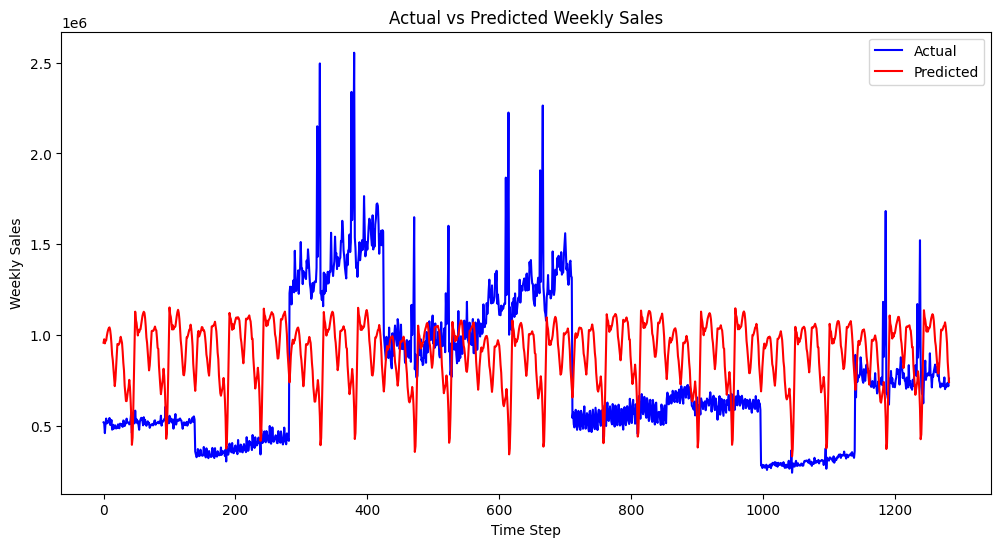

In [56]:
# Plot actual vs predicted values
plt.figure(figsize=(12, 6))
plt.plot(y_test_actual.flatten(), label='Actual', color='blue')
plt.plot(y_pred.flatten(), label='Predicted', color='red')
plt.legend()
plt.title('Actual vs Predicted Weekly Sales')
plt.xlabel('Time Step')
plt.ylabel('Weekly Sales')
plt.savefig('Predicted_Sales_2.png',transparent=True)
plt.show()

While the error is still relatively large due to high sales figures (~$200.000 to ~$1.000.000), the model is still considered more reliable now. The hyperparameter tuning process really helped the model capture the underlying patterns better.

# 21) Conclusions

- The main problem seems to lie on the nature of the dataset as we can see in the heatmap and scatter plots earlier in the EDA section in this project. The exogenous factors don’t have a clear linear relationship with weekly sales which makes the models struggle to make meaningful predictions.
  
- I have tried using several other methods including SARIMAX and XGboost and they performed even worse than the LSTM model used in this project. If there is no discernible relationship between the features and the target, any model, no matter how sophisticated, is likely to perform poorly.

- The weak performance of the model could also be caused be due to too many exogenous factors that introduce noise rather than useful predictive signals.

- Exogenous factors (like unemployment, temperature, fuel price, CPI, holiday effects) can impact sales, but their influence is often non-linear and context-dependent. For example, high unemployment could reduce spending, but if a holiday coincides with a stimulus check, sales might increase instead. This makes it difficult for a model to learn consistent patterns from the data.

- Weekly sales patterns could highly depend on external factors not captured in the dataset (e.g., promotions, marketing campaigns, competitor activities, macroeconomic trends, store-specific changes, stimulus checks, etc.).

# 22)  Further Improvements for the Model

- Reduce exogenous factors: instead of using all exogenous factors, test only with one strong predictor (e.g, only use Unemployment or Temperature) to avoid conflict issues between every exogenous factors involved.
  
- Use only past weekly sales data: the model can learn better if there is no exogenous factors involved. This reduces complexity as the model only learns from single feature only. This makes it a pure time series forecasting problem, which is often easier to model.